# ATLAS v0.4 — Early ICU Deterioration Prediction

## Clinical Question
Can routinely collected vital signs during the first 6 hours of ICU admission identify patients at increased risk of subsequent clinical deterioration?

## Study Design
- Observation window: first 6 hours of ICU stay
- Prediction period: after the first 6 hours
- Data source: MIMIC-IV demo
- Initial model: Logistic Regression
- Priorities: temporal validity, leakage prevention, and interpretability

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("../data/mimic-demo")

HOSP_DIR = DATA_DIR / "hosp"
ICU_DIR = DATA_DIR / "icu"

print("HOSP exists:", HOSP_DIR.exists())
print("ICU exists:", ICU_DIR.exists())
print("HOSP path:", HOSP_DIR.resolve())
print("ICU path:", ICU_DIR.resolve())

HOSP exists: True
ICU exists: True
HOSP path: C:\Users\klobn\OneDrive\Desktop\ATLAS\data\mimic-demo\hosp
ICU path: C:\Users\klobn\OneDrive\Desktop\ATLAS\data\mimic-demo\icu


In [2]:
patients = pd.read_csv(HOSP_DIR / "patients.csv.gz")
icu = pd.read_csv(ICU_DIR / "icustays.csv.gz")
chart = pd.read_csv(ICU_DIR / "chartevents.csv.gz")

print("Patients shape:", patients.shape)
print("ICU stays shape:", icu.shape)
print("Chart events shape:", chart.shape)

Patients shape: (100, 6)
ICU stays shape: (140, 8)
Chart events shape: (668862, 11)


In [3]:
print("Unique patients in ICU:", icu["subject_id"].nunique())
print("Unique ICU stays:", icu["stay_id"].nunique())

print("Unique patients in chart events:", chart["subject_id"].nunique())
print("Unique ICU stays in chart events:", chart["stay_id"].nunique())

Unique patients in ICU: 100
Unique ICU stays: 140
Unique patients in chart events: 100
Unique ICU stays in chart events: 140


In [4]:
d_items = pd.read_csv(ICU_DIR / "d_items.csv.gz")

print("d_items shape:", d_items.shape)

terms = [
    "heart rate",
    "systolic",
    "spo2",
    "oxygen saturation",
    "respiratory rate"
]

mask = d_items["label"].str.lower().fillna("").apply(
    lambda x: any(term in x for term in terms)
)

vital_candidates = d_items.loc[
    mask,
    ["itemid", "label", "unitname", "category"]
].sort_values("label")

vital_candidates

d_items shape: (4014, 9)


,itemid,label,unitname,category
2563,225309,ART BP Systolic,mmHg,Routine Vital Signs
2186,228152,Aortic Pressure Signal - Systolic,mmHg.,Impella
2586,220050,Arterial Blood Pressure systolic,mmHg,Routine Vital Signs
2890,229862,Forehead SpO2 Sensor in Place,NaN,Routine Vital Signs
2577,220045,Heart Rate,bpm,Routine Vital Signs
2054,220047,Heart Rate Alarm - Low,bpm,Alarms
2063,220046,Heart rate Alarm - High,bpm,Alarms
2177,229899,Left Ventricular Pressure Signal - Systolic,mmHg,Impella
2591,224167,Manual Blood Pressure Systolic Left,mmHg,Routine Vital Signs
2571,227243,Manual Blood Pressure Systolic Right,mmHg,Routine Vital Signs


In [5]:
candidate_ids = {
    "HR": [220045],
    "SBP": [220050, 220179, 225309],
    "RR": [220210, 224688, 224689, 224690],
    "SpO2": [220277]
}

rows = []

for vital, ids in candidate_ids.items():
    for itemid in ids:
        subset = chart[chart["itemid"] == itemid]

        label_row = d_items[d_items["itemid"] == itemid]

        label = (
            label_row["label"].iloc[0]
            if len(label_row) > 0
            else "Not found"
        )

        rows.append({
            "vital": vital,
            "itemid": itemid,
            "label": label,
            "rows": len(subset),
            "patients": subset["subject_id"].nunique(),
            "icu_stays": subset["stay_id"].nunique()
        })

coverage = pd.DataFrame(rows)
coverage

,vital,itemid,label,rows,patients,icu_stays
0,HR,220045,Heart Rate,13913,100,140
1,SBP,220050,Arterial Blood Pressure systolic,5525,56,65
2,SBP,220179,Non Invasive Blood Pressure systolic,8347,100,139
3,SBP,225309,ART BP Systolic,486,9,10
4,RR,220210,Respiratory Rate,13913,100,140
5,RR,224688,Respiratory Rate (Set),801,53,63
6,RR,224689,Respiratory Rate (spontaneous),1314,55,66
7,RR,224690,Respiratory Rate (Total),1331,56,67
8,SpO2,220277,O2 saturation pulseoxymetry,13540,100,140


In [6]:
# Final vital-sign item IDs selected from MIMIC-IV d_items
VITAL_ITEMS = {
    220045: "HR",
    220179: "SBP",
    220210: "RR",
    220277: "SpO2"
}

# Convert timestamps
icu["intime"] = pd.to_datetime(icu["intime"])
chart["charttime"] = pd.to_datetime(chart["charttime"])

# Keep only selected vital-sign measurements
vitals = chart[
    chart["itemid"].isin(VITAL_ITEMS.keys())
][["subject_id", "stay_id", "itemid", "charttime", "valuenum"]].copy()

# Add readable vital name
vitals["vital"] = vitals["itemid"].map(VITAL_ITEMS)

# Add ICU admission time
vitals = vitals.merge(
    icu[["stay_id", "intime"]],
    on="stay_id",
    how="inner"
)

# Time since ICU admission
vitals["hours_from_icu"] = (
    vitals["charttime"] - vitals["intime"]
).dt.total_seconds() / 3600

# Observation window = first 6 hours
vitals_6h = vitals[
    (vitals["hours_from_icu"] >= 0) &
    (vitals["hours_from_icu"] <= 6)
].copy()

print("All selected vital rows:", len(vitals))
print("Rows in first 6 hours:", len(vitals_6h))
print("ICU stays represented:", vitals_6h["stay_id"].nunique())

vitals_6h.head()

All selected vital rows: 49713
Rows in first 6 hours: 4224
ICU stays represented: 139


,subject_id,stay_id,itemid,charttime,valuenum,vital,intime,hours_from_icu
149,10005817,32604416,220277,2132-12-15 15:00:00,100.0,SpO2,2132-12-15 09:29:01,5.516389
150,10005817,32604416,220045,2132-12-15 15:00:00,62.0,HR,2132-12-15 09:29:01,5.516389
151,10005817,32604416,220210,2132-12-15 15:00:00,15.0,RR,2132-12-15 09:29:01,5.516389
177,10005817,32604416,220045,2132-12-15 14:12:00,80.0,HR,2132-12-15 09:29:01,4.716389
178,10005817,32604416,220277,2132-12-15 14:12:00,100.0,SpO2,2132-12-15 09:29:01,4.716389


In [7]:
coverage_6h = (
    vitals_6h
    .groupby(["stay_id", "vital"])
    .size()
    .unstack(fill_value=0)
)

print("Number of ICU stays with each vital in first 6 hours:")
print((coverage_6h > 0).sum())

print("\nICU stays with all four vital signs:")
print((coverage_6h > 0).all(axis=1).sum())

Number of ICU stays with each vital in first 6 hours:
vital
HR      139
RR      139
SBP     108
SpO2    139
dtype: int64

ICU stays with all four vital signs:
108


In [8]:
SBP_IDS = [
    220179,  # Non Invasive Blood Pressure systolic
    220050,  # Arterial Blood Pressure systolic
    225309,  # ART BP Systolic
    224167,  # Manual Blood Pressure Systolic Left
    227243   # Manual Blood Pressure Systolic Right
]

sbp_test = chart[
    chart["itemid"].isin(SBP_IDS)
][["stay_id", "itemid", "charttime", "valuenum"]].copy()

sbp_test["charttime"] = pd.to_datetime(sbp_test["charttime"])

sbp_test = sbp_test.merge(
    icu[["stay_id", "intime"]],
    on="stay_id",
    how="inner"
)

sbp_test["hours_from_icu"] = (
    sbp_test["charttime"] - sbp_test["intime"]
).dt.total_seconds() / 3600

sbp_6h = sbp_test[
    (sbp_test["hours_from_icu"] >= 0) &
    (sbp_test["hours_from_icu"] <= 6)
].copy()

print("ICU stays with any SBP source in first 6 hours:",
      sbp_6h["stay_id"].nunique())

print("\nCoverage by SBP item ID:")
print(
    sbp_6h.groupby("itemid")["stay_id"]
    .nunique()
    .sort_values(ascending=False)
)

ICU stays with any SBP source in first 6 hours: 138

Coverage by SBP item ID:
itemid
220179    108
220050     50
225309      2
224167      1
227243      1
Name: stay_id, dtype: int64


In [9]:
# ICU stay duration in hours
icu["outtime"] = pd.to_datetime(icu["outtime"])

icu["icu_hours"] = (
    icu["outtime"] - icu["intime"]
).dt.total_seconds() / 3600

print("Total ICU stays:", len(icu))

print("\nStays >= 6 hours:")
print((icu["icu_hours"] >= 6).sum())

print("\nStays >= 18 hours:")
print((icu["icu_hours"] >= 18).sum())

print("\nStays >= 24 hours:")
print((icu["icu_hours"] >= 24).sum())

print("\nStays >= 30 hours:")
print((icu["icu_hours"] >= 30).sum())

icu["icu_hours"].describe()

Total ICU stays: 140

Stays >= 6 hours:
137

Stays >= 18 hours:
128

Stays >= 24 hours:
117

Stays >= 30 hours:
96


count    140.000000
mean      88.305097
std       93.512500
min        0.569444
25%       28.095903
50%       51.722222
75%      117.785972
max      492.688333
Name: icu_hours, dtype: float64

In [10]:
eligible_stays = icu.loc[
    icu["icu_hours"] >= 30,
    "stay_id"
]

print("Eligible ICU stays for full 24h prediction window:",
      eligible_stays.nunique())

print("Of these, stays with SBP in first 6 hours:",
      sbp_6h[sbp_6h["stay_id"].isin(eligible_stays)]["stay_id"].nunique())

Eligible ICU stays for full 24h prediction window: 96
Of these, stays with SBP in first 6 hours: 96


In [11]:
# Build future vital-sign data for the 24h prediction window

FUTURE_ITEMS = {
    220045: "HR",
    220179: "SBP",
    220050: "SBP",
    225309: "SBP",
    224167: "SBP",
    227243: "SBP",
    220210: "RR",
    220277: "SpO2"
}

future_vitals = chart[
    chart["itemid"].isin(FUTURE_ITEMS.keys())
][["stay_id", "itemid", "charttime", "valuenum"]].copy()

future_vitals["vital"] = future_vitals["itemid"].map(FUTURE_ITEMS)
future_vitals["charttime"] = pd.to_datetime(future_vitals["charttime"])

future_vitals = future_vitals.merge(
    icu[["stay_id", "intime"]],
    on="stay_id",
    how="inner"
)

future_vitals["hours_from_icu"] = (
    future_vitals["charttime"] - future_vitals["intime"]
).dt.total_seconds() / 3600

future_vitals = future_vitals[
    future_vitals["stay_id"].isin(eligible_stays) &
    (future_vitals["hours_from_icu"] > 6) &
    (future_vitals["hours_from_icu"] <= 30)
].copy()

print("Future-window rows:", len(future_vitals))
print("ICU stays represented:", future_vitals["stay_id"].nunique())

Future-window rows: 10869
ICU stays represented: 96


In [12]:
# Explore candidate deterioration events

hypotension = future_vitals[
    (future_vitals["vital"] == "SBP") &
    (future_vitals["valuenum"] < 90)
]

hypoxemia = future_vitals[
    (future_vitals["vital"] == "SpO2") &
    (future_vitals["valuenum"] < 90)
]

tachypnea = future_vitals[
    (future_vitals["vital"] == "RR") &
    (future_vitals["valuenum"] >= 30)
]

tachycardia = future_vitals[
    (future_vitals["vital"] == "HR") &
    (future_vitals["valuenum"] >= 130)
]

print("Eligible stays:", len(eligible_stays))

print("\nSBP < 90:",
      hypotension["stay_id"].nunique())

print("SpO2 < 90:",
      hypoxemia["stay_id"].nunique())

print("RR >= 30:",
      tachypnea["stay_id"].nunique())

print("HR >= 130:",
      tachycardia["stay_id"].nunique())

composite_ids = set(hypotension["stay_id"]) | set(hypoxemia["stay_id"])

print("\nSBP < 90 OR SpO2 < 90:",
      len(composite_ids))

Eligible stays: 96

SBP < 90: 50
SpO2 < 90: 19
RR >= 30: 25
HR >= 130: 12

SBP < 90 OR SpO2 < 90: 57


In [13]:
# Remove clearly implausible measurements before defining the endpoint

future_clean = future_vitals.copy()

future_clean = future_clean[
    (
        (future_clean["vital"] == "HR") &
        future_clean["valuenum"].between(20, 250)
    ) |
    (
        (future_clean["vital"] == "SBP") &
        future_clean["valuenum"].between(40, 250)
    ) |
    (
        (future_clean["vital"] == "RR") &
        future_clean["valuenum"].between(5, 80)
    ) |
    (
        (future_clean["vital"] == "SpO2") &
        future_clean["valuenum"].between(50, 100)
    )
].copy()

print("Rows before cleaning:", len(future_vitals))
print("Rows after cleaning:", len(future_clean))

Rows before cleaning: 10869
Rows after cleaning: 10856


In [14]:
# Candidate persistent deterioration:
# at least 2 abnormal measurements at distinct times

low_sbp = future_clean[
    (future_clean["vital"] == "SBP") &
    (future_clean["valuenum"] < 90)
]

low_spo2 = future_clean[
    (future_clean["vital"] == "SpO2") &
    (future_clean["valuenum"] < 90)
]

sbp_counts = (
    low_sbp.groupby("stay_id")["charttime"]
    .nunique()
)

spo2_counts = (
    low_spo2.groupby("stay_id")["charttime"]
    .nunique()
)

persistent_sbp_ids = set(
    sbp_counts[sbp_counts >= 2].index
)

persistent_spo2_ids = set(
    spo2_counts[spo2_counts >= 2].index
)

persistent_deterioration_ids = (
    persistent_sbp_ids |
    persistent_spo2_ids
)

print("Persistent SBP < 90:", len(persistent_sbp_ids))
print("Persistent SpO2 < 90:", len(persistent_spo2_ids))
print(
    "Persistent SBP < 90 OR SpO2 < 90:",
    len(persistent_deterioration_ids)
)

print(
    "Event rate:",
    round(
        len(persistent_deterioration_ids)
        / len(eligible_stays) * 100,
        1
    ),
    "%"
)

Persistent SBP < 90: 37
Persistent SpO2 < 90: 4
Persistent SBP < 90 OR SpO2 < 90: 39
Event rate: 40.6 %


In [15]:
# Build the final 6-hour observation dataset

OBS_ITEMS = {
    220045: "HR",

    # Systolic blood pressure sources
    220179: "SBP",
    220050: "SBP",
    225309: "SBP",
    224167: "SBP",
    227243: "SBP",

    220210: "RR",
    220277: "SpO2"
}

obs_vitals = chart[
    chart["itemid"].isin(OBS_ITEMS.keys())
][["stay_id", "itemid", "charttime", "valuenum"]].copy()

obs_vitals["vital"] = obs_vitals["itemid"].map(OBS_ITEMS)
obs_vitals["charttime"] = pd.to_datetime(obs_vitals["charttime"])

obs_vitals = obs_vitals.merge(
    icu[["stay_id", "intime"]],
    on="stay_id",
    how="inner"
)

obs_vitals["hours_from_icu"] = (
    obs_vitals["charttime"] - obs_vitals["intime"]
).dt.total_seconds() / 3600

# Only the first 6 hours and only eligible stays
obs_vitals = obs_vitals[
    obs_vitals["stay_id"].isin(eligible_stays) &
    (obs_vitals["hours_from_icu"] >= 0) &
    (obs_vitals["hours_from_icu"] <= 6)
].copy()

print("Observation rows:", len(obs_vitals))
print("Eligible ICU stays represented:",
      obs_vitals["stay_id"].nunique())

Observation rows: 3359
Eligible ICU stays represented: 96


In [16]:
obs_clean = obs_vitals[
    (
        (obs_vitals["vital"] == "HR") &
        obs_vitals["valuenum"].between(20, 250)
    ) |
    (
        (obs_vitals["vital"] == "SBP") &
        obs_vitals["valuenum"].between(40, 250)
    ) |
    (
        (obs_vitals["vital"] == "RR") &
        obs_vitals["valuenum"].between(5, 80)
    ) |
    (
        (obs_vitals["vital"] == "SpO2") &
        obs_vitals["valuenum"].between(50, 100)
    )
].copy()

print("Rows before cleaning:", len(obs_vitals))
print("Rows after cleaning:", len(obs_clean))
print("ICU stays after cleaning:",
      obs_clean["stay_id"].nunique())

Rows before cleaning: 3359
Rows after cleaning: 3357
ICU stays after cleaning: 96


In [17]:
# Aggregate the first 6 hours into interpretable features

features = (
    obs_clean
    .groupby(["stay_id", "vital"])["valuenum"]
    .agg(["mean", "min", "max", "std"])
    .unstack("vital")
)

# Flatten column names
features.columns = [
    f"{vital}_{stat}"
    for stat, vital in features.columns
]

features = features.reset_index()

print("Feature table shape:", features.shape)
features.head()

Feature table shape: (96, 17)


,stay_id,HR_mean,RR_mean,SBP_mean,SpO2_mean,HR_min,RR_min,SBP_min,SpO2_min,HR_max,RR_max,SBP_max,SpO2_max,HR_std,RR_std,SBP_std,SpO2_std
0,30057454,105.916667,19.250000,97.666667,93.500000,100.0,14.0,86.0,90.0,114.0,23.0,112.0,96.0,4.316108,2.767506,7.535773,1.930615
1,30101877,102.166667,20.000000,132.000000,100.000000,89.0,18.0,102.0,100.0,123.0,24.0,150.0,100.0,12.750163,2.280351,17.899721,0.000000
2,30425410,101.500000,21.500000,100.857143,100.000000,91.0,15.0,90.0,100.0,113.0,29.0,108.0,100.0,6.969321,4.035556,6.743604,0.000000
3,30458995,71.750000,17.000000,138.000000,97.625000,60.0,15.0,122.0,89.0,83.0,19.0,151.0,99.0,9.483068,1.309307,11.618950,3.502550
4,30585761,70.000000,17.333333,132.000000,95.333333,65.0,10.0,125.0,94.0,73.0,22.0,139.0,98.0,2.756810,4.082483,5.585696,1.505545


In [18]:
print("Missing values per feature:")
print(
    features.isna()
    .sum()
    .sort_values(ascending=False)
)

Missing values per feature:
stay_id      0
HR_max       0
SBP_std      0
RR_std       0
HR_std       0
SpO2_max     0
SBP_max      0
RR_max       0
SpO2_min     0
HR_mean      0
SBP_min      0
RR_min       0
HR_min       0
SpO2_mean    0
SBP_mean     0
RR_mean      0
SpO2_std     0
dtype: int64


In [19]:
# Build modeling cohort with patient ID and age

cohort = icu[
    icu["stay_id"].isin(eligible_stays)
][["subject_id", "stay_id", "intime"]].copy()

cohort = cohort.merge(
    patients[
        ["subject_id", "anchor_age", "anchor_year"]
    ],
    on="subject_id",
    how="left"
)

# Approximate age at ICU admission
cohort["age"] = (
    cohort["anchor_age"]
    + cohort["intime"].dt.year
    - cohort["anchor_year"]
)

# Add the persistent physiological deterioration outcome
cohort["outcome"] = (
    cohort["stay_id"]
    .isin(persistent_deterioration_ids)
    .astype(int)
)

model_df = cohort[
    ["subject_id", "stay_id", "age", "outcome"]
].merge(
    features,
    on="stay_id",
    how="inner"
)

print("Modeling dataset shape:", model_df.shape)
print("\nOutcome distribution:")
print(model_df["outcome"].value_counts())

print("\nOutcome rate:")
print(model_df["outcome"].mean().round(3))

print("\nUnique patients:")
print(model_df["subject_id"].nunique())

print("\nPatients with >1 eligible ICU stay:")
print(
    (model_df.groupby("subject_id").size() > 1).sum()
)

model_df.head()

Modeling dataset shape: (96, 20)

Outcome distribution:
outcome
0    57
1    39
Name: count, dtype: int64

Outcome rate:
0.406

Unique patients:
72

Patients with >1 eligible ICU stay:
16


,subject_id,stay_id,age,outcome,HR_mean,RR_mean,SBP_mean,SpO2_mean,HR_min,RR_min,SBP_min,SpO2_min,HR_max,RR_max,SBP_max,SpO2_max,HR_std,RR_std,SBP_std,SpO2_std
0,10018328,31269608,83,0,73.000000,18.500000,134.000000,98.000000,70.0,16.0,120.0,97.0,75.0,21.0,147.0,100.0,1.673320,1.870829,10.099505,1.264911
1,10020187,37509585,63,0,75.571429,16.857143,117.833333,96.000000,66.0,15.0,108.0,93.0,92.0,20.0,130.0,98.0,9.360505,2.267787,8.727352,2.081666
2,10012853,31338022,92,1,66.714286,20.750000,144.500000,93.142857,57.0,15.0,127.0,90.0,73.0,27.0,164.0,96.0,5.794086,4.200340,15.056560,2.340126
3,10039708,38559363,48,1,82.500000,19.833333,92.833333,98.500000,71.0,17.0,89.0,97.0,90.0,23.0,98.0,100.0,6.379655,2.136976,3.250641,1.048809
4,10020306,38540883,80,1,97.142857,16.714286,94.714286,97.750000,83.0,10.0,79.0,96.0,107.0,25.0,106.0,100.0,8.820971,5.964179,10.904346,1.752549


In [20]:
print("Age summary:")
print(model_df["age"].describe())

print("\nMissing values in final modeling table:")
print(model_df.isna().sum().sort_values(ascending=False).head())

Age summary:
count    96.000000
mean     62.906250
std      16.215703
min      21.000000
25%      51.750000
50%      63.500000
75%      75.750000
max      92.000000
Name: age, dtype: float64

Missing values in final modeling table:
subject_id    0
stay_id       0
SBP_std       0
RR_std        0
HR_std        0
dtype: int64


In [22]:
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    recall_score
)

In [23]:
# Compact, clinically interpretable baseline feature set

feature_cols = [
    "age",
    "HR_mean",
    "HR_max",
    "RR_mean",
    "RR_max",
    "SBP_mean",
    "SBP_min",
    "SpO2_mean",
    "SpO2_min"
]

X = model_df[feature_cols]
y = model_df["outcome"]
groups = model_df["subject_id"]

print("X shape:", X.shape)
print("Positive cases:", y.sum())
print("Negative cases:", (y == 0).sum())
print("Unique patients:", groups.nunique())

X shape: (96, 9)
Positive cases: 39
Negative cases: 57
Unique patients: 72


In [24]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        max_iter=2000,
        random_state=42
    ))
])

# Out-of-fold predicted probabilities
y_prob = cross_val_predict(
    pipeline,
    X,
    y,
    groups=groups,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Classification at conventional 0.50 threshold
y_pred = (y_prob >= 0.50).astype(int)

auc = roc_auc_score(y, y_prob)
auprc = average_precision_score(y, y_prob)

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"AUROC:      {auc:.3f}")
print(f"AUPRC:      {auprc:.3f}")
print(f"Sensitivity:{sensitivity:.3f}")
print(f"Specificity:{specificity:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y, y_pred))

AUROC:      0.682
AUPRC:      0.650
Sensitivity:0.513
Specificity:0.737

Confusion matrix:
[[42 15]
 [19 20]]


In [25]:
def persistent_ids_with_min_gap(df, vital, threshold, direction="low", min_gap_minutes=30):
    x = df[df["vital"] == vital].copy()

    if direction == "low":
        x = x[x["valuenum"] < threshold]
    else:
        x = x[x["valuenum"] >= threshold]

    persistent_ids = set()

    for stay_id, g in x.groupby("stay_id"):
        times = g["charttime"].sort_values().drop_duplicates()

        if len(times) < 2:
            continue

        first_time = times.iloc[0]

        if ((times - first_time).dt.total_seconds() / 60 >= min_gap_minutes).any():
            persistent_ids.add(stay_id)

    return persistent_ids


persistent_sbp_30 = persistent_ids_with_min_gap(
    future_clean,
    vital="SBP",
    threshold=90,
    direction="low",
    min_gap_minutes=30
)

persistent_spo2_30 = persistent_ids_with_min_gap(
    future_clean,
    vital="SpO2",
    threshold=90,
    direction="low",
    min_gap_minutes=30
)

persistent_deterioration_30 = (
    persistent_sbp_30 |
    persistent_spo2_30
)

print("Persistent SBP < 90, >=30 min apart:",
      len(persistent_sbp_30))

print("Persistent SpO2 < 90, >=30 min apart:",
      len(persistent_spo2_30))

print("Composite persistent deterioration:",
      len(persistent_deterioration_30))

print("Event rate:",
      round(len(persistent_deterioration_30) / len(eligible_stays) * 100, 1),
      "%")

Persistent SBP < 90, >=30 min apart: 36
Persistent SpO2 < 90, >=30 min apart: 4
Composite persistent deterioration: 38
Event rate: 39.6 %


In [26]:
# Final outcome definition for ATLAS v0.4
# Persistent physiological instability in the 6–30 h window:
# ≥2 SBP < 90 mmHg or SpO2 < 90% measurements
# separated by at least 30 minutes

model_df["outcome"] = (
    model_df["stay_id"]
    .isin(persistent_deterioration_30)
    .astype(int)
)

print("Final outcome distribution:")
print(model_df["outcome"].value_counts())

print("\nFinal event rate:")
print(model_df["outcome"].mean().round(3))

Final outcome distribution:
outcome
0    58
1    38
Name: count, dtype: int64

Final event rate:
0.396


In [27]:
# Final outcome definition for ATLAS v0.4
# Persistent physiological instability in the 6–30 h window:
# ≥2 SBP < 90 mmHg or SpO2 < 90% measurements
# separated by at least 30 minutes

model_df["outcome"] = (
    model_df["stay_id"]
    .isin(persistent_deterioration_30)
    .astype(int)
)

print("Final outcome distribution:")
print(model_df["outcome"].value_counts())

print("\nFinal event rate:")
print(model_df["outcome"].mean().round(3))

Final outcome distribution:
outcome
0    58
1    38
Name: count, dtype: int64

Final event rate:
0.396


In [28]:
X = model_df[feature_cols]
y = model_df["outcome"]
groups = model_df["subject_id"]

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        max_iter=2000,
        random_state=42
    ))
])

y_prob = cross_val_predict(
    pipeline,
    X,
    y,
    groups=groups,
    cv=cv,
    method="predict_proba"
)[:, 1]

y_pred = (y_prob >= 0.50).astype(int)

auc = roc_auc_score(y, y_prob)
auprc = average_precision_score(y, y_prob)

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"AUROC:       {auc:.3f}")
print(f"AUPRC:       {auprc:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y, y_pred))

AUROC:       0.691
AUPRC:       0.612
Sensitivity: 0.526
Specificity: 0.724

Confusion matrix:
[[42 16]
 [18 20]]


In [29]:
from sklearn.model_selection import cross_validate

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_results = cross_validate(
    pipeline,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Fold AUROC:")
print(np.round(cv_results["test_roc_auc"], 3))

print(
    "\nMean AUROC:",
    round(cv_results["test_roc_auc"].mean(), 3)
)

print(
    "SD AUROC:",
    round(cv_results["test_roc_auc"].std(), 3)
)

print("\nFold AUPRC:")
print(np.round(cv_results["test_average_precision"], 3))

print(
    "\nMean AUPRC:",
    round(cv_results["test_average_precision"].mean(), 3)
)

print(
    "SD AUPRC:",
    round(cv_results["test_average_precision"].std(), 3)
)

Fold AUROC:
[0.717 0.612 0.742 0.677 0.836]

Mean AUROC: 0.717
SD AUROC: 0.074

Fold AUPRC:
[0.596 0.382 0.54  0.818 0.834]

Mean AUPRC: 0.634
SD AUPRC: 0.172


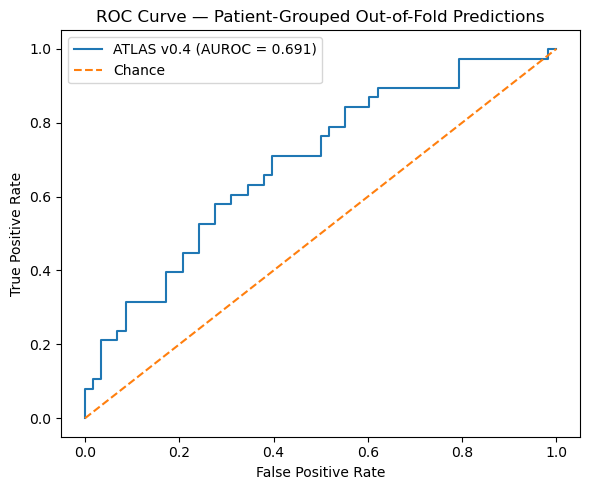

In [30]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)

# ROC curve from out-of-fold predictions
fpr, tpr, _ = roc_curve(y, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ATLAS v0.4 (AUROC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Patient-Grouped Out-of-Fold Predictions")
plt.legend()
plt.tight_layout()

plt.savefig("../images/atlas_v4_roc_curve.png", dpi=300)
plt.show()

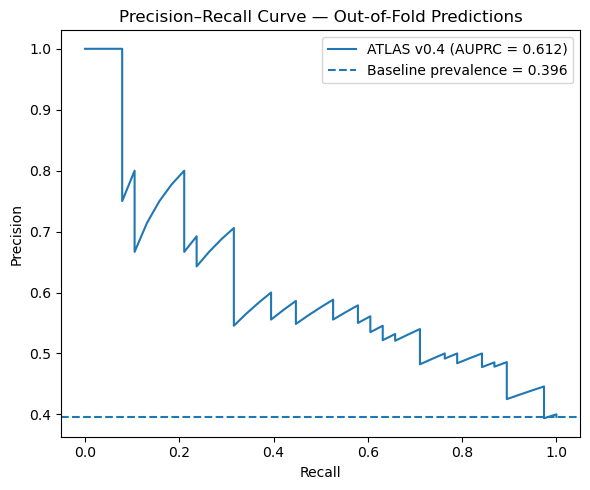

In [31]:
precision, recall, _ = precision_recall_curve(y, y_prob)

baseline = y.mean()

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"ATLAS v0.4 (AUPRC = {auprc:.3f})")
plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline prevalence = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Out-of-Fold Predictions")
plt.legend()
plt.tight_layout()

plt.savefig("../images/atlas_v4_pr_curve.png", dpi=300)
plt.show()

In [32]:
# Fit the final pipeline on the full cohort
# This fit is used only for coefficient interpretation,
# not for performance estimation.

pipeline.fit(X, y)

coef = pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coef
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_df

,feature,coefficient,abs_coefficient
6,SBP_min,-0.705702,0.705702
5,SBP_mean,-0.528849,0.528849
4,RR_max,-0.382208,0.382208
2,HR_max,0.324163,0.324163
0,age,0.322908,0.322908
1,HR_mean,0.219771,0.219771
8,SpO2_min,-0.195002,0.195002
3,RR_mean,-0.156152,0.156152
7,SpO2_mean,-0.131999,0.131999


## Results

ATLAS v0.4 was evaluated using patient-grouped 5-fold cross-validation, ensuring that ICU stays from the same patient were never split across training and validation folds.

### Cohort
- 96 eligible ICU stays
- 72 unique patients
- 38 deterioration events (39.6%)

### Performance
- Mean 5-fold AUROC: 0.717 ± 0.074
- Mean 5-fold AUPRC: 0.634 ± 0.172
- Pooled out-of-fold AUROC: 0.691
- Pooled out-of-fold AUPRC: 0.612
- Sensitivity at 0.50 threshold: 0.526
- Specificity at 0.50 threshold: 0.724

The precision–recall performance exceeded the event-prevalence baseline (0.396), suggesting that early vital-sign patterns contain predictive signal for subsequent physiological instability.

## Interpretation

Lower systolic blood pressure during the first 6 hours showed the strongest association with subsequent physiological instability.

Because several engineered variables are correlated (for example, mean and minimum values from the same vital sign), individual logistic-regression coefficients should not be interpreted causally or in isolation.

The model is intended as an interpretable proof of concept rather than a clinically deployable prediction system.

## Limitations

- Small MIMIC-IV demo cohort
- Proxy physiological endpoint rather than a validated clinical deterioration endpoint
- Limited clinical variables
- No external validation
- Correlated summary features may affect individual coefficient estimates
- Results should not be interpreted as evidence of clinical utility

## Next Steps

Future versions of ATLAS will evaluate larger MIMIC-IV cohorts, richer temporal features, clinically validated endpoints, and more advanced models while preserving strict temporal separation and patient-level validation.